# Generating Embeddings using Hugging Face (Free models)

**Level:** Scratch → Intermediate
**Runs on:** Google Colab (Free CPU/GPU)

### What you will learn
1. What an embedding is (in simple words)
2. Installing free, open Hugging Face libraries
3. Generating embeddings with `sentence-transformers`
4. Comparing text similarity using cosine similarity
5. Visualizing embeddings in 2D
6. Building a mini Semantic Search engine (intermediate project)

> No API key needed. No paid model used. Everything here runs on the free Hugging Face open-source models.

## 1. What is an Embedding?

- An **embedding** is a list of numbers (a vector) that represents the *meaning* of a piece of text.
- Similar sentences → similar (close) vectors.
- Different sentences → far apart vectors.

Example:
- "I love dogs" and "I like puppies" → vectors will be **close**
- "I love dogs" and "The stock market crashed" → vectors will be **far apart**

We will use the `sentence-transformers` library, which uses free Hugging Face models.

### 2. Install Required Libraries
Run this once. `-q` keeps the output quiet (low token / clean output).

In [1]:
%pip install pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -q sentence-transformers scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 3. Load a Free Hugging Face Model

We are using **`all-MiniLM-L6-v2`** — a small, fast, completely free open-source model from Hugging Face.
- Size: ~80MB
- Great for learning and even production use
- Output: 384-dimensional embedding vector per sentence

In [3]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully!


### 4. Generate Your First Embedding

In [5]:
sentence = "I love learning about Artificial Intelligence."

embedding = model.encode(sentence)

print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634458 -0.07657031  0.04107474  0.01962835  0.05804771 -0.05071755
  0.0388935   0.03076571  0.05800404  0.06948569]


**Discussion Point:** Notice the embedding has 384 numbers. These numbers don't mean anything individually — but together, they capture the *meaning* of the sentence.

### 5. Generate Embeddings for Multiple Sentences

In [6]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


### 6. Measure Similarity Between Sentences

We use **Cosine Similarity** to check how close two embeddings are.
- Score close to `1` → very similar meaning
- Score close to `0` → unrelated meaning
- Score close to `-1` → opposite meaning (rare with text)

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


**Important Discussion Point:**
Look at the similarity score between *"I love dogs"* and *"I like puppies"* — it should be high.
Compare that to *"I love dogs"* vs *"The stock market crashed today"* — it should be low.

This is the **core idea behind semantic search, chatbots, and recommendation systems**.

### 7. Visualize Embeddings in 2D (using PCA)
Embeddings have 384 dimensions — we can't see that. So we reduce it to 2D just to *visualize* how sentences cluster.

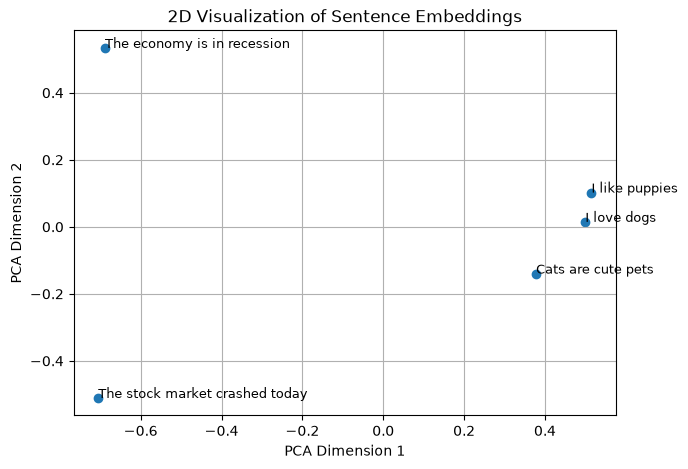

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

**Discussion Point:** Sentences with similar meaning (dogs/puppies, stock/economy) should appear **closer together** in the plot, even though we never told the model to group them manually.

## 8. Intermediate Project: Mini Semantic Search Engine

**Goal:** Given a user query, find the most relevant sentence from a small database — using meaning, not just matching words.

In [9]:
# Our small "document" database
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")

# Try it
semantic_search("Tell me about AI and neural networks")

Query: Tell me about AI and neural networks

Score: 0.534  |  Deep learning uses neural networks with many layers.
Score: 0.524  |  Python is a popular programming language for AI.


In [10]:
# Try another query
semantic_search("What is the capital of France?")

Query: What is the capital of France?

Score: 0.824  |  Paris is the capital city of France.
Score: 0.102  |  Python is a popular programming language for AI.


### 9. Key Takeaways (Recap for Students)

| Concept | Meaning |
|---|---|
| Embedding | Numeric vector representing meaning of text |
| Model used | `all-MiniLM-L6-v2` (free, open-source, Hugging Face) |
| Cosine Similarity | Measures how close two embeddings are |
| Semantic Search | Finding relevant text by meaning, not exact words |
| PCA | Used only to visualize high-dimension vectors in 2D |

### 10. Practice Exercises (for students)
1. Replace the `documents` list with your own 10 sentences and test `semantic_search`.
2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.
3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.

In [11]:
documents = [
    "Python is a popular programming language.",
    "Machine learning allows computers to learn from data.",
    "Artificial intelligence is used in many industries.",
    "Java is an object-oriented programming language.",
    "Data science combines programming, statistics, and mathematics.",
    "Neural networks are inspired by the human brain.",
    "Semantic search finds information based on meaning.",
    "Natural language processing helps computers understand human language.",
    "Deep learning uses neural networks with multiple layers.",
    "Computer vision allows computers to understand images."
]

semantic_search("What is machine learning?", top_k=3)

Query: What is machine learning?

Score: 0.633  |  Artificial intelligence is used in many industries.
Score: 0.447  |  Data science combines programming, statistics, and mathematics.
Score: 0.390  |  Python is a popular programming language.


In [12]:
model = SentenceTransformer("all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\icl\gen-ai-tasks\venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dhude\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
doc_embeddings = model.encode(documents)

In [14]:
semantic_search("What is machine learning?", top_k=3)

Query: What is machine learning?

Score: 0.712  |  Machine learning allows computers to learn from data.
Score: 0.470  |  Artificial intelligence is used in many industries.
Score: 0.424  |  Computer vision allows computers to understand images.


### Comparison of Embedding Models

I tested the same query, "What is machine learning?", using two models.

- `all-MiniLM-L6-v2` produced a top score of 0.633.
- `all-mpnet-base-v2` produced a top score of 0.712.
- The `all-mpnet-base-v2` model returned "Machine learning allows computers to learn from data" as the top result, which is closely related to the query.
- The results show that different embedding models can produce different similarity scores and search results.

In [15]:
faq_questions = [
    "What is Python?",
    "What is machine learning?",
    "What is artificial intelligence?",
    "What is deep learning?",
    "What is computer vision?"
]

faq_answers = [
    "Python is a popular programming language.",
    "Machine learning allows computers to learn from data.",
    "Artificial intelligence enables computers to perform tasks that normally require human intelligence.",
    "Deep learning uses neural networks with multiple layers.",
    "Computer vision allows computers to understand images."
]

In [16]:
faq_embeddings = model.encode(faq_questions)

In [17]:
def faq_bot(question):
    question_embedding = model.encode([question])
    
    scores = cosine_similarity(question_embedding, faq_embeddings)[0]
    
    best_idx = scores.argmax()
    
    print("Question:", question)
    print("Answer:", faq_answers[best_idx])
    print("Similarity Score:", round(scores[best_idx], 3))

In [18]:
faq_bot("How can computers learn from information?")

Question: How can computers learn from information?
Answer: Machine learning allows computers to learn from data.
Similarity Score: 0.589


In [19]:
faq_bot("What technology helps computers understand pictures?")

Question:

 What technology helps computers understand pictures?
Answer: Computer vision allows computers to understand images.
Similarity Score: 0.616
